0.0014
0.000784
0.000784


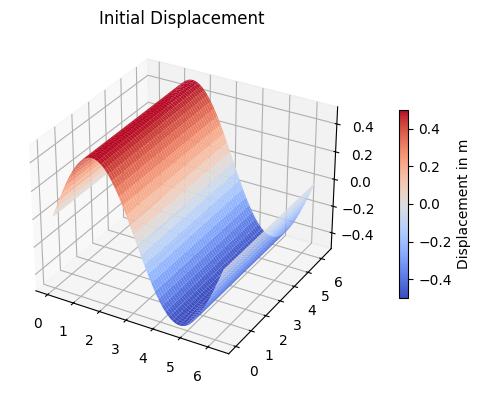

In [4]:
## Import Library
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

## Plate dimensions in Meters
X=2*np.pi
Y=2*np.pi
## Simulations Parameters
#mesh size 
del_x=0.01
del_y=0.01
h=0.01
#material properties
E=3e+4
nu=0.3
G=E/((1-nu)*2)
Rho=11000
#speed of wave in medium
ws=(G/Rho)**0.5
# Simulation time in S
c=0.2
delt= round(c*h/ws,4) 
print(delt)
tot_time=20
rx= round(((c*delt)/del_x)**2,6) 
ry= round(((c*delt)/del_y)**2,6)
print(rx)    
print(ry)

## grid_points
x=np.linspace(0,X,100)
y=np.linspace(0,Y,100)
a,b=np.meshgrid(x,y)

## Initial Condition
Z=np.sin(a)/2
Z_previ=Z
Z_crnt=Z_previ
Z_next=np.zeros([100,100])
Z_displacement=[]
## Plot Initial Condition
fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111, projection="3d")
surf=ax.plot_surface(a,b,Z,cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)

plt.title("Initial Displacement")
plt.tight_layout()
plt.show()

In [5]:
## Solve the Equation with Central Difference Method
for t in range(0,int(tot_time/delt)):
    for i in range(1,99):
        for j in range(1,99):
            Z_disp= 2*Z_crnt[i,j] - Z_previ[i,j] + (rx)*(Z_crnt[i+1,j] - 2*Z_crnt[i,j] + Z_crnt[i-1,j]) + (ry) * (Z_crnt[i,j+1] - 2*Z_crnt[i,j] + Z_crnt[i,j-1])
            Z_next[i][j]=Z_disp
    Z_previ= Z_crnt.copy()
    Z_crnt=Z_next.copy()
    Z_displacement.append(Z_crnt)

/var/folders/br/fy_nl9d92znbdsxrh0253n0w0000gn/T/ipykernel_6838/3330966526.py:9: UserWarning: Adding colorbar to a different Figure <Figure size 500x500 with 2 Axes> than <Figure size 500x500 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)


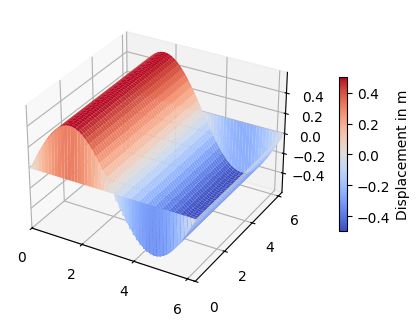

In [7]:
## Create GIF Animation:
zmin = Z.min()
zmax = Z.max()
zlim_margin = (zmax - zmin) * 0.1

fig=plt.figure(figsize=(5,5))
ax=fig.add_subplot(111,projection="3d")
ax.plot_surface(a,b,Z_displacement[0], cmap="coolwarm")
fig.colorbar(surf,ax=ax,label="Displacement in m",shrink=0.4,pad=0.1)
ax.set_zlim(zmin - zlim_margin, zmax + zlim_margin)

ax.set_title("Vibration of Plate")

def animate(i):
    ax.clear()
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(0, 2*np.pi)
    ax.set_zlim(zmin - zlim_margin, zmax + zlim_margin)
    ax.plot_surface(a,b,Z_displacement[i], cmap="coolwarm")

anim=animation.FuncAnimation(fig,animate,frames=range(0,int(tot_time/delt),10))
writer=animation.FFMpegWriter(fps=(30))
anim.save("Vibration_of_Plate_sinewave.mp4",writer=writer)